Original Shape: (70000, 13)
Cleaned Shape: (68494, 13)


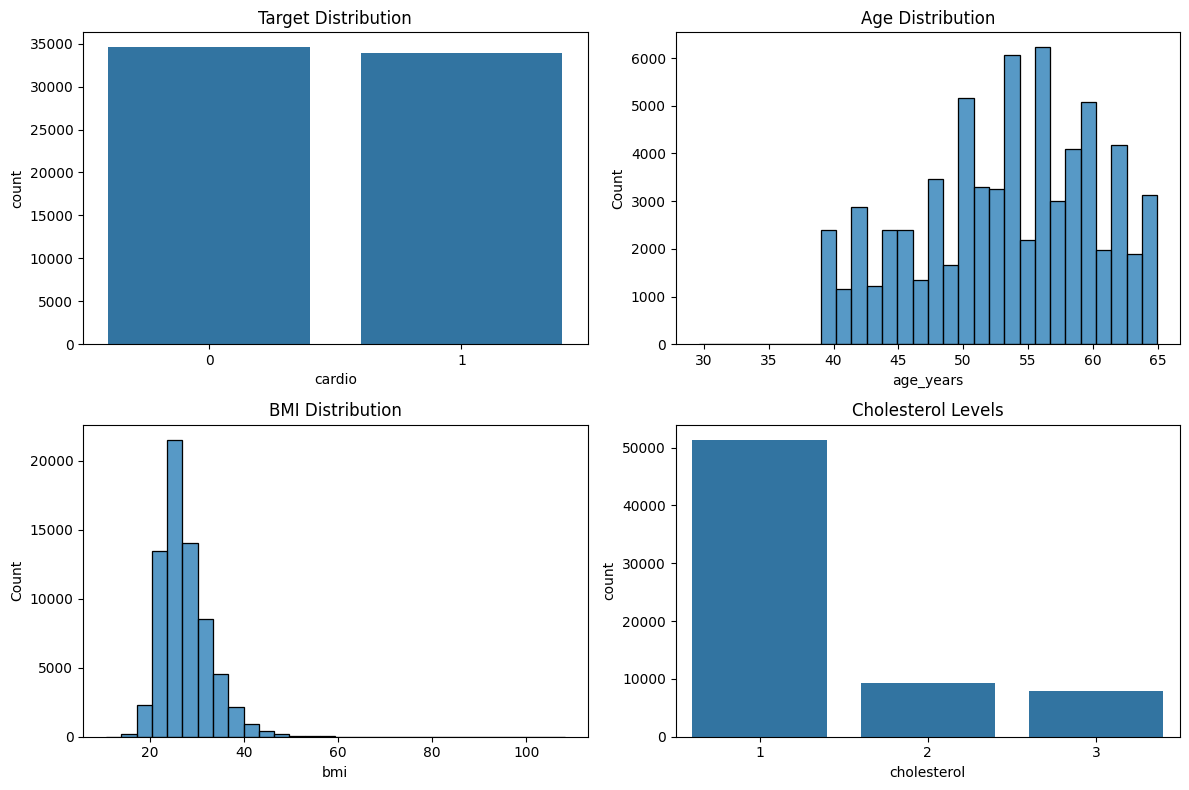

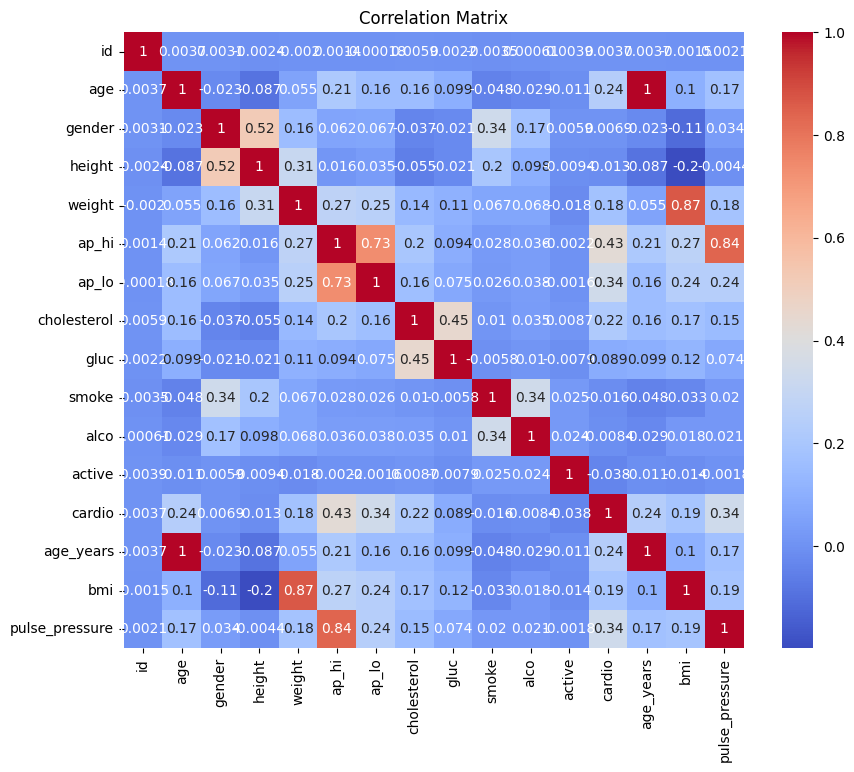


=== MODEL RESULTS ===

Logistic Regression
Accuracy: 0.729
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6918
           1       0.76      0.67      0.71      6781

    accuracy                           0.73     13699
   macro avg       0.73      0.73      0.73     13699
weighted avg       0.73      0.73      0.73     13699


Random Forest
Accuracy: 0.7335
              precision    recall  f1-score   support

           0       0.71      0.80      0.75      6918
           1       0.77      0.67      0.71      6781

    accuracy                           0.73     13699
   macro avg       0.74      0.73      0.73     13699
weighted avg       0.74      0.73      0.73     13699



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# -------------------------------
# LOAD DATA
# -------------------------------

df = pd.read_csv('/content/cardio_train (1).csv', sep=';')
print("Original Shape:", df.shape)

# -------------------------------
# DATA PREPROCESSING
# -------------------------------

# Remove invalid values
df = df[(df['ap_hi'] > 80) & (df['ap_hi'] < 250)]
df = df[(df['ap_lo'] > 40) & (df['ap_lo'] < 150)]
df = df[df['ap_hi'] > df['ap_lo']]

df = df[(df['height'] > 120) & (df['height'] < 220)]
df = df[(df['weight'] > 30) & (df['weight'] < 200)]

print("Cleaned Shape:", df.shape)

# Feature Engineering
df['age_years'] = df['age'] / 365
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

# -------------------------------
# DATA VISUALIZATION
# -------------------------------

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.countplot(x='cardio', data=df)
plt.title("Target Distribution")

plt.subplot(2,2,2)
sns.histplot(df['age_years'], bins=30)
plt.title("Age Distribution")

plt.subplot(2,2,3)
sns.histplot(df['bmi'], bins=30)
plt.title("BMI Distribution")

plt.subplot(2,2,4)
sns.countplot(x='cholesterol', data=df)
plt.title("Cholesterol Levels")

plt.tight_layout()
plt.show()

# -------------------------------
# CORRELATION MATRIX
# -------------------------------

plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# -------------------------------
# FEATURES & TARGET
# -------------------------------

features = [
    'age_years', 'gender', 'height', 'weight',
    'ap_hi', 'ap_lo', 'pulse_pressure',
    'cholesterol', 'gluc', 'smoke', 'alco',
    'active', 'bmi'
]

X = df[features]
y = df['cardio']

# -------------------------------
# TRAIN TEST SPLIT
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# SCALING
# -------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------
# MODELS
# -------------------------------

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, weights='distance'),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42)
}

# -------------------------------
# TRAIN & EVALUATE
# -------------------------------

accuracies = {}

print("\n=== MODEL RESULTS ===")

for name, model in models.items():

    if name in ["Random Forest", "Decision Tree"]:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, pred)
    accuracies[name] = acc

    print(f"\n{name}")
    print("Accuracy:", round(acc,4))
    print(classification_report(y_test, pred))

# -------------------------------
# ACCURACY COMPARISON
# -------------------------------

plt.figure()
plt.bar(accuracies.keys(), accuracies.values())
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# -------------------------------
# BEST MODEL
# -------------------------------

best_model = max(accuracies, key=accuracies.get)
print("\nBest Model:", best_model)

# -------------------------------
# CONFUSION MATRIX
# -------------------------------

best_pred = pred  # last prediction (optional improvement: store separately)

cm = confusion_matrix(y_test, pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f'Confusion Matrix - {best_model}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# -------------------------------
# FEATURE IMPORTANCE (RF)
# -------------------------------

rf = models["Random Forest"]
importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nFeature Importance:\n", importance)

plt.figure()
sns.barplot(x='importance', y='feature', data=importance)
plt.title("Feature Importance - Random Forest")
plt.show()